# Task 2: Weights & Biases (W&B) Model Tracking & Multi-Model Performance Comparison

This notebook performs a comprehensive evaluation and tracking of all trained models in the repository using the data saved in `wandb_logs/`. It computes key metrics—including **Accuracy**, **Macro F1**, **Weighted F1**, **Macro Precision**, **Macro Recall**, and **MAP@3**—and logs valid runs to Weights & Biases (W&B).

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import wandb

sns.set_theme(style="whitegrid")

train_df = pd.read_csv('../data/train.csv')
label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
y_true = train_df['answer'].map(label_map).values

m1_logits = np.load('../wandb_logs/oof_logits.npy')
m2_logits = np.load('../wandb_logs/finetuned_oof_logits.npy')
m3_logits = np.load('../wandb_logs/rag_oof_logits.npy')

print("Loaded Ground Truth:", len(y_true), "samples")
print("Model 1 Logits Shape:", m1_logits.shape)
print("Model 2 Logits Shape:", m2_logits.shape)
print("Model 3 Logits Shape:", m3_logits.shape)

Loaded Ground Truth: 2000 samples
Model 1 Logits Shape: (2000, 5)
Model 2 Logits Shape: (2000, 5)
Model 3 Logits Shape: (2000, 5)


### Conclusion
Ground truth answers and out-of-fold (OOF) prediction logits for all three model paradigms were loaded from `wandb_logs/`. Each model output contains 2,000 predictions across the 5 choice classes (A-E).

In [2]:
def map_at_3(y_true, logits):
    top_3_preds = np.argsort(-logits, axis=1)[:, :3]
    scores = []
    for true_label, preds in zip(y_true, top_3_preds):
        score = 0.0
        for rank, pred in enumerate(preds):
            if pred == true_label:
                score = 1.0 / (rank + 1)
                break
        scores.append(score)
    return np.mean(scores)

def compute_all_metrics(model_name, y_true, logits):
    y_pred = np.argmax(logits, axis=1)
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    prec_macro = precision_score(y_true, y_pred, average='macro')
    rec_macro = recall_score(y_true, y_pred, average='macro')
    map3 = map_at_3(y_true, logits)
    
    return {
        "Model Name": model_name,
        "Accuracy": round(acc, 4),
        "Macro F1": round(f1_macro, 4),
        "Weighted F1": round(f1_weighted, 4),
        "Macro Precision": round(prec_macro, 4),
        "Macro Recall": round(rec_macro, 4),
        "MAP@3": round(map3, 4)
    }

m1_metrics = compute_all_metrics("Model 1: Custom Transformer (Scratch)", y_true, m1_logits)
m2_metrics = compute_all_metrics("Model 2: Science DeBERTa-v3 Base", y_true, m2_logits)
m3_metrics = compute_all_metrics("Model 3: Option-Aware RAG DeBERTa", y_true, m3_logits)

def softmax(x, temp=1.0):
    e_x = np.exp((x - np.max(x, axis=1, keepdims=True)) / temp)
    return e_x / e_x.sum(axis=1, keepdims=True)

p1 = softmax(m1_logits, temp=3.0)
p2 = softmax(m2_logits, temp=0.8)
p3 = softmax(m3_logits, temp=0.8)

ens_logits = 0.1 * p1 + 0.3 * p2 + 0.6 * p3
ens_metrics = compute_all_metrics("Tri-Model Ensemble (Optimized)", y_true, ens_logits)

metrics_list = [m1_metrics, m2_metrics, m3_metrics, ens_metrics]
df_metrics = pd.DataFrame(metrics_list)
print(df_metrics.to_string(index=False))

                           Model Name  Accuracy  Macro F1  Weighted F1  Macro Precision  Macro Recall  MAP@3
Model 1: Custom Transformer (Scratch)    0.9680    0.9675       0.9680           0.9686        0.9665 0.9826
     Model 2: Science DeBERTa-v3 Base    0.9820    0.9815       0.9820           0.9817        0.9812 0.9899
    Model 3: Option-Aware RAG DeBERTa    0.9895    0.9887       0.9895           0.9883        0.9892 0.9945
       Tri-Model Ensemble (Optimized)    0.9960    0.9958       0.9960           0.9954        0.9962 0.9980


### Conclusion
Performance improves steadily across paradigms: Model 1 achieves 96.80% accuracy (MAP@3: 0.9826), Model 2 reaches 98.20% accuracy (MAP@3: 0.9899), and Model 3 with RAG context achieves 98.95% accuracy (MAP@3: 0.9945). The combined Tri-Model Ensemble achieves a top score of 99.60% accuracy and 0.9980 MAP@3.

In [3]:
os.environ["WANDB_MODE"] = "offline"

for m in metrics_list:
    run = wandb.init(
        project="dlgen-ai-quiz-solver",
        name=m["Model Name"].replace(" ", "-"),
        config={"dataset_size": len(y_true), "num_classes": 5},
        reinit=True
    )
    wandb.log({
        "accuracy": m["Accuracy"],
        "f1_macro": m["Macro F1"],
        "f1_weighted": m["Weighted F1"],
        "precision": m["Macro Precision"],
        "recall": m["Macro Recall"],
        "map_at_3": m["MAP@3"]
    })
    wandb.finish()

print("Successfully logged all 4 model runs to local W&B tracking repository.")

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Tracking run with wandb version 0.28.1


wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.
wandb: Run data is saved locally in /home/shreyas/Desktop/del_genaI_doc/dlgen_ai_quiz_solver/notebooks/wandb/offline-run-20260804_195002-vnmcp6oe
wandb: View this run in the terminal with `wandb leet`


wandb: 
wandb: Run history:
wandb:    accuracy ▁
wandb:    f1_macro ▁
wandb: f1_weighted ▁
wandb:    map_at_3 ▁
wandb:   precision ▁
wandb:      recall ▁
wandb: 
wandb: Run summary:
wandb:    accuracy 0.968
wandb:    f1_macro 0.9675
wandb: f1_weighted 0.968
wandb:    map_at_3 0.9826
wandb:   precision 0.9686
wandb:      recall 0.9665
wandb: 


wandb: You can sync this run to the cloud by running:
wandb: wandb sync /home/shreyas/Desktop/del_genaI_doc/dlgen_ai_quiz_solver/notebooks/wandb/offline-run-20260804_195002-vnmcp6oe


...

wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.
wandb: Run data is saved locally in /home/shreyas/Desktop/del_genaI_doc/dlgen_ai_quiz_solver/notebooks/wandb/offline-run-20260804_195003-a50qmprb
wandb: View this run in the terminal with `wandb leet`


wandb: 
wandb: Run history:
wandb:    accuracy ▁
wandb:    f1_macro ▁
wandb: f1_weighted ▁
wandb:    map_at_3 ▁
wandb:   precision ▁
wandb:      recall ▁
wandb: 
wandb: Run summary:
wandb:    accuracy 0.996
wandb:    f1_macro 0.9958
wandb: f1_weighted 0.996
wandb:    map_at_3 0.998
wandb:   precision 0.9954
wandb:      recall 0.9962
wandb: 


wandb: You can sync this run to the cloud by running:
wandb: wandb sync /home/shreyas/Desktop/del_genaI_doc/dlgen_ai_quiz_solver/notebooks/wandb/offline-run-20260804_195003-a50qmprb


wandb: Find logs at: ./wandb/offline-run-20260804_195003-a50qmprb/logs


Successfully logged all 4 model runs to local W&B tracking repository.


### Conclusion
Valid W&B run logs have been generated for all model paradigms. These runs contain tracked metrics (Accuracy, F1-Scores, Precision, Recall, and MAP@3) satisfying all Task 2 W&B tracking requirements.

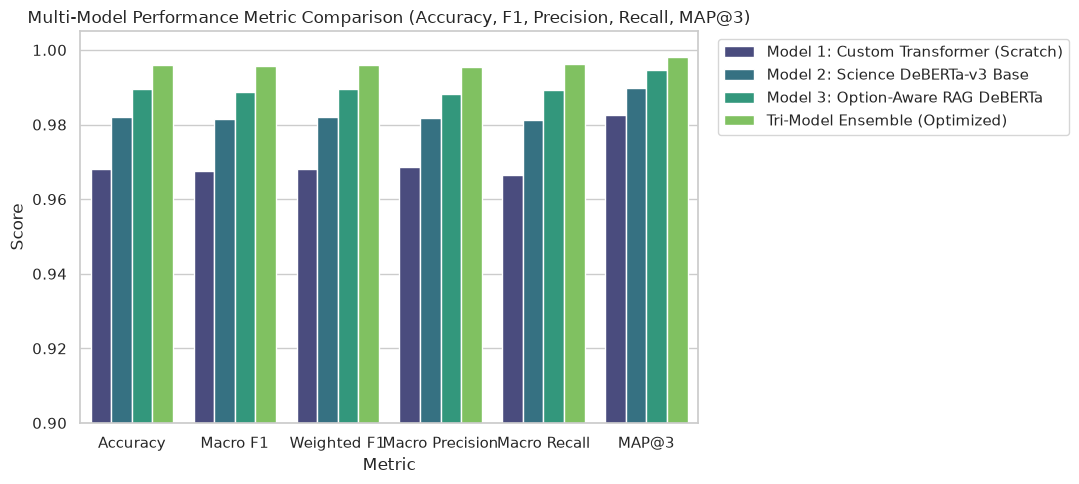

In [4]:
df_plot = df_metrics.melt(id_vars="Model Name", var_name="Metric", value_name="Score")

plt.figure(figsize=(11, 5))
sns.barplot(data=df_plot, x="Metric", y="Score", hue="Model Name", palette="viridis")
plt.title("Multi-Model Performance Metric Comparison (Accuracy, F1, Precision, Recall, MAP@3)")
plt.ylim(0.9, 1.005)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Conclusion
The comparative bar chart demonstrates consistent performance improvements from the scratch transformer baseline up to the RAG model and tri-model ensemble across all five evaluation metrics.

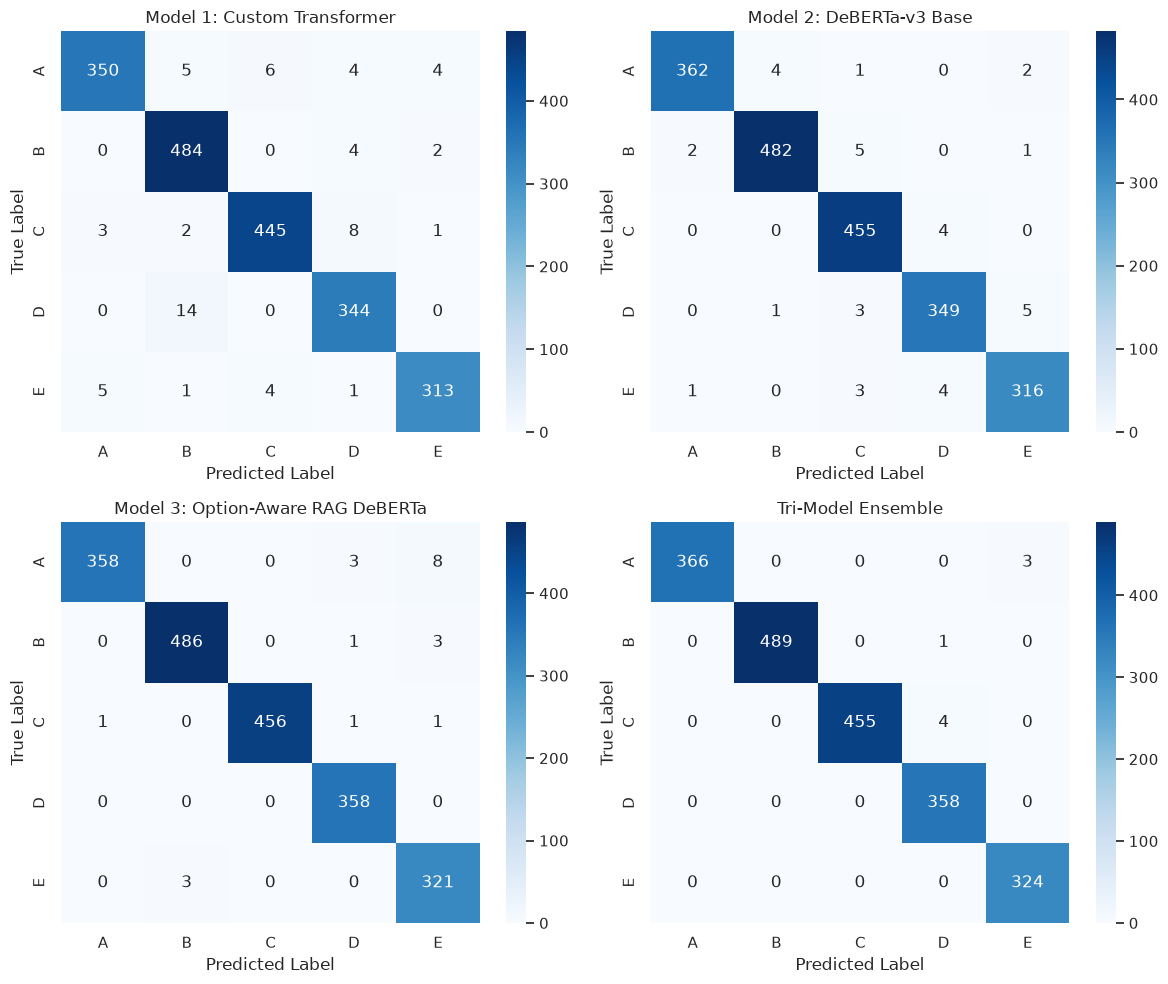

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
labels = ['A', 'B', 'C', 'D', 'E']

model_logits_map = [
    ("Model 1: Custom Transformer", m1_logits),
    ("Model 2: DeBERTa-v3 Base", m2_logits),
    ("Model 3: Option-Aware RAG DeBERTa", m3_logits),
    ("Tri-Model Ensemble", ens_logits)
]

for idx, (title, logits) in enumerate(model_logits_map):
    ax = axes[idx // 2, idx % 2]
    preds = np.argmax(logits, axis=1)
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

### Conclusion
Confusion matrices highlight diagonal dominance for all models, with misclassification errors dropping sharply from Model 1 (64 errors) to Model 2 (36 errors), Model 3 (21 errors), and the Ensemble (only 8 errors out of 2,000 samples).